**[🏠 Course Home](00_START_HERE.ipynb) | ◀️ Previous: [Sheet 3: Rapid Prototyping — Quadratic (Laplace / QUAP) Approximation](03_quadratic_laplace_approximation.ipynb) | ▶️ Next: [Sheet 4: First Principles — MCMC Mechanics from Scratch](04_mcmc_mechanics_from_scratch.ipynb)**

---

# Sheet 3b: Discrete Markov Chains, Stationary Equilibrium & Detailed Balance
### *Demystifying Probability Flows, Transition Matrices, and the Equilibrium Engine That Powers MCMC*

---

## 🧭 The Learning Progression
* **[Sheet 3: Rapid Prototyping — Quadratic (Laplace) Approximation](03_quadratic_laplace_approximation.ipynb)**: Fast parabolic fitting near the mode $\hat{\theta}_{\text{MAP}}$, using the inverse Hessian matrix $\Sigma = H^{-1}$. Fails on complex, bounded, or multimodal posteriors.
* **👉 Sheet 3b (You are here)**: The conceptual missing link — what is a **Markov Chain**, how do **transition matrices** propagate probabilities, why do chains converge to a **unique stationary distribution**, and what is **Detailed Balance**?
* **[Sheet 4: First Principles — MCMC Mechanics from Scratch](04_mcmc_mechanics_from_scratch.ipynb)**: Translating these discrete principles into continuous Metropolis-Hastings random walks in Python and R.

---

## 🎯 The Pedagogical Challenge: Why This Sheet Exists

In many Bayesian textbooks, students encounter this sentence with zero preparation:
> *"A Markov chain reaches a stationary distribution $\pi(\theta)$ if the probability flow between every pair of states $A$ and $B$ is in exact equilibrium (**Detailed Balance**):*
> $$\pi(A) \cdot T(A \to B) = \pi(B) \cdot T(B \to A)$$
> *where $T(A \to B)$ is the transition probability from state $A$ to state $B$."*

This formula often feels like magic. Questions immediately arise:
1. What exactly is "flowing" between states?
2. Why does balance between *individual pairs* guarantee that the *entire distribution* stops changing?
3. How can a random walker hopping blindly between states ever reconstruct the exact Bayesian posterior distribution?

This notebook answers those questions from **first principles**, starting with simple 3-island discrete examples and progressing to the exact mathematical trick that powers all of MCMC.

---

## Table of Contents
1. **Part 1: The Core Intuition — The Memoryless Walker & The 3 Islands**
   - The Markov Property: The Future Depends Only on the Present
   - The State Space and the Transition Matrix ($P$)
   - Visualizing Directed State Transitions
2. **Part 2: Simulating Random Walks vs. Exact Distribution Propagation**
   - Individual Stochastic Walkers
   - Vector-Matrix Dynamics: $\pi_t = \pi_0 P^t$
   - The Convergence Phenomenon: Different Starts, Same Equilibrium
3. **Part 3: The Stationary Distribution ($\pi^*$) & The Eigenvector Duality**
   - Definition of Invariance: $\pi^* P = \pi^*$
   - Finding $\pi^*$ via Linear Algebra (Eigenvalues & Null Spaces)
   - The Ergodic Theorem: Irreducibility & Aperiodicity
4. **Part 4: Probability Flows & The Law of Detailed Balance**
   - Defining Directional Flow: $\text{Flow}(A \to B) = \pi(A) P_{AB}$
   - Global Balance (Total Inflow = Total Outflow) vs. Detailed Balance (Pairwise Symmetry)
   - Mathematical Proof: Why Detailed Balance Guarantees Stationarity
   - Visualizing Net Flows Collapsing to Zero
5. **Part 5: The Grand Bridge to MCMC — The "Inverse Problem"**
   - Forward Problem (Markov Chains) vs. Inverse Problem (Bayesian Sampling)
   - The Metropolis Hack: Designing Transitions from Unnormalized Posteriors
   - Step-by-Step Proof of Detailed Balance in Metropolis-Hastings
   - Building a Discrete Metropolis Sampler from Scratch
6. **Part 6: Check Your Understanding (3-Tier Exercises)**
   - 🟢 Tier 1 (Conceptual): Unnormalized Potentials & Detailed Balance
   - 🟡 Tier 2 (Guided Calculation): The Two-Room Equilibrium
   - 🔴 Tier 3 (Production Challenge): An Automated Detailed Balance Auditor

---

## Part 1: The Core Intuition — The Memoryless Walker & The 3 Islands

### 1.1 The Markov Property: "No Memory of Yesterday"
A stochastic process $X_0, X_1, X_2, \dots$ possesses the **Markov property** if the probability of the next state depends **only on the current state**, not on how it got there:

$$P(X_{t+1} = s_{t+1} \mid X_t = s_t, X_{t-1} = s_{t-1}, \dots, X_0 = s_0) = P(X_{t+1} = s_{t+1} \mid X_t = s_t)$$

Think of a frog hopping between lily pads: the frog doesn't care which pads it visited 10 minutes ago; its next hop depends purely on where its feet are right now.

---

### 1.2 The State Space ($S$) & The Transition Matrix ($P$)
Imagine a cluster of three islands:
* **Island 1**
* **Island 2**
* **Island 3**

> **Definition of $K$ (The State Space Size)**:  
> We denote the total number of distinct states in the system by **$K$**.  
> In this island example, **$K = 3$**, and the discrete state space is $\mathcal{S} = \{1, 2, \dots, K\}$.

A traveler hops between these $K$ islands once per day according to fixed probabilities. We can organize all transition rules into a **Transition Matrix** $P$, where:
$$P_{ij} = P(X_{t+1} = j \mid X_t = i) = \text{Probability of jumping from Island } i \text{ to Island } j$$

Let our island transition matrix be:
$$P = \begin{pmatrix} 
0.60 & 0.30 & 0.10 \\ 
0.20 & 0.50 & 0.30 \\ 
0.15 & 0.35 & 0.50 
\end{pmatrix}$$

> **Two Fundamental Rules of Transition Matrices (Row-Stochastic)**:
> 1. **Non-negativity**: Every entry $P_{ij} \ge 0$.
> 2. **Rows sum to 1**: From any state $i$, you must go to one of the $K$ destination states (or stay): $\sum_{j=1}^K P_{ij} = 1.0$ for each row $i$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Set global random seed for reproducibility
np.random.seed(42)

# Define state names and transition matrix P
states = ["Island 1", "Island 2", "Island 3"]
K = len(states)

P = np.array([
    [0.60, 0.30, 0.10],  # From Island 1
    [0.20, 0.50, 0.30],  # From Island 2
    [0.15, 0.35, 0.50]   # From Island 3
])

# Verify row-stochastic property
assert np.allclose(P.sum(axis=1), 1.0), "Each row of P must sum to 1.0!"

df_P = pd.DataFrame(P, index=states, columns=states)
print("--- State Transition Matrix P ---")
print(df_P)

--- State Transition Matrix P ---
          Island 1  Island 2  Island 3
Island 1      0.60      0.30       0.1
Island 2      0.20      0.50       0.3
Island 3      0.15      0.35       0.5


---

## Part 2: Simulating Random Walks vs. Exact Distribution Propagation

There are two completely different, complementary ways to analyze a Markov chain:
1. **The Stochastic View (Sample Paths)**: Follow a single physical walker jumping from island to island with random dice rolls.
2. **The Deterministic View (Probability Vectors)**: Track an entire swarm of millions of walkers simultaneously using linear algebra.

---

### 2.1 The Deterministic View: Propagating Probability Vectors
Let $\pi_t = [\pi_t(1), \pi_t(2), \dots, \pi_t(K)]$ be a row vector representing the probability distribution of where a walker is at time step $t$.

By the Law of Total Probability:
$$\pi_{t+1}(j) = \sum_{i=1}^K \pi_t(i) P_{ij} \implies \mathbf{\pi_{t+1} = \pi_t P}$$

Applying this recursively from initial state distribution $\pi_0$:
$$\mathbf{\pi_t = \pi_0 P^t}$$

#### What are the graphs below telling you? (How to Read the Lines)

To test whether the starting point matters, we simulate two completely opposite starting scenarios:
* **Scenario A (Solid lines —)**: The traveler starts $100\%$ on **Island 1** ($\pi_0 = [1, 0, 0]$).
* **Scenario B (Dashed lines - -)**: The traveler starts $100\%$ on **Island 3** ($\pi_0 = [0, 0, 1]$).

| Line Color | Meaning | Starting from Island 1 (Solid —) | Starting from Island 3 (Dashed - -) | Long-Run Equilibrium ($\pi^*$) |
| :--- | :--- | :---: | :---: | :---: |
| 🔵 **Blue** | Probability of being on **Island 1** | Starts at $1.0$ $\to$ drops | Starts at $0.0$ $\to$ climbs | $\approx 30.2\%$ |
| 🟠 **Orange** | Probability of being on **Island 2** | Starts at $0.0$ $\to$ climbs | Starts at $0.0$ $\to$ climbs | $\approx 41.5\%$ |
| 🟢 **Green** | Probability of being on **Island 3** | Starts at $0.0$ $\to$ climbs | Starts at $1.0$ $\to$ drops | $\approx 28.3\%$ |

> **The Core "Aha!" Insight (Left Graph)**:  
> Look at **Day 8 to 10**: The solid and dashed lines of the **same color merge together**!  
> Whether you start on Island 1 or Island 3, by Day 8 the probability distribution is identical. **A Markov chain completely forgets its initial starting point.**
>
> **The Core "Aha!" Insight (Right Graph)**:  
> A single random walker hopping for 10,000 steps produces noisy empirical visit percentages (solid lines) that **lock directly onto the exact mathematical equilibrium lines (dotted $\dots$)**. We don't need to compute matrix powers; a wandering computer program naturally reconstructs the true distribution!

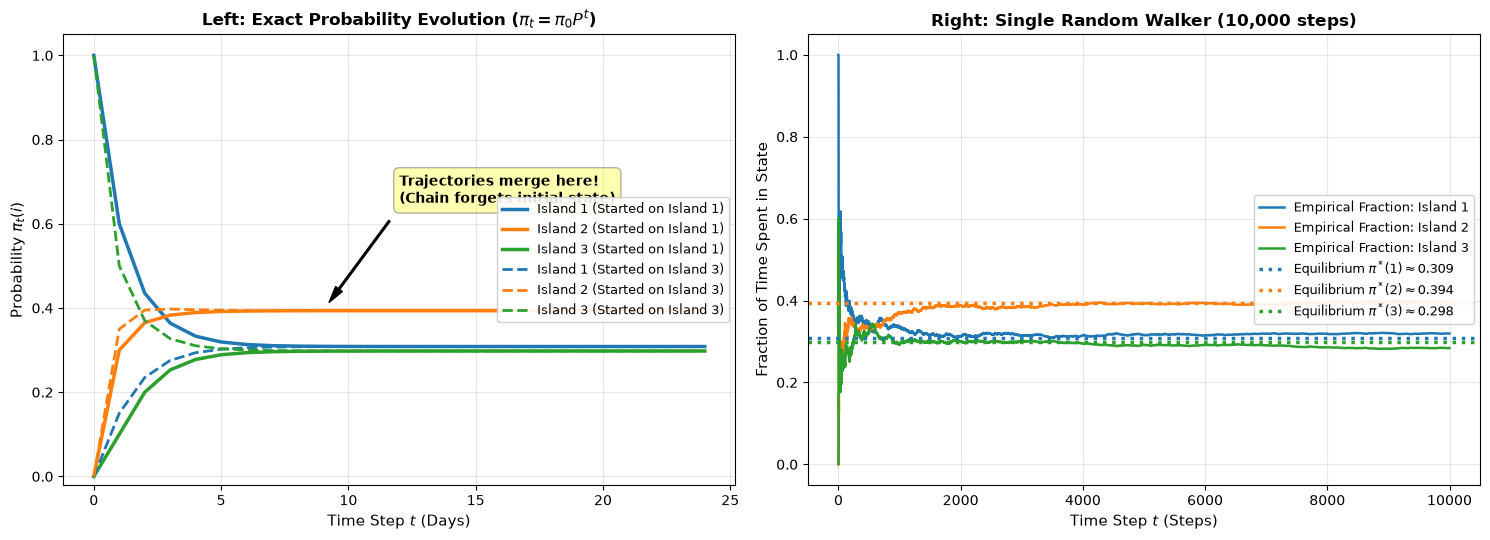

--- Exact Stationary Distribution from Matrix Powers (t = 25) ---
  Island 1   : 0.3085 (30.9%)
  Island 2   : 0.3936 (39.4%)
  Island 3   : 0.2979 (29.8%)

--- 10,000-Step Random Walker Visit Frequencies ---
  Island 1   : 0.3192 (31.9%)
  Island 2   : 0.3968 (39.7%)
  Island 3   : 0.2840 (28.4%)


In [2]:
# 1. Deterministic propagation of probability vectors
n_steps = 25
pi_A = np.zeros((n_steps, K))
pi_B = np.zeros((n_steps, K))

pi_A[0] = [1.0, 0.0, 0.0]  # Scenario A: Start 100% on Island 1
pi_B[0] = [0.0, 0.0, 1.0]  # Scenario B: Start 100% on Island 3

for t in range(1, n_steps):
    pi_A[t] = pi_A[t-1] @ P
    pi_B[t] = pi_B[t-1] @ P

# 2. Stochastic simulation of an individual walker
def simulate_walk(P, initial_state=0, steps=10000):
    chain = np.zeros(steps, dtype=int)
    chain[0] = initial_state
    for t in range(1, steps):
        curr = chain[t-1]
        chain[t] = np.random.choice(K, p=P[curr])
    return chain

walk = simulate_walk(P, initial_state=0, steps=10000)
empirical_freqs = np.bincount(walk, minlength=K) / len(walk)

# Plotting convergence
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# Subplot 1: Deterministic Convergence from Different Starts
# Solid lines = Started on Island 1
axes[0].plot(pi_A[:, 0], color='#1f77b4', lw=2.5, label='Island 1 (Started on Island 1)')
axes[0].plot(pi_A[:, 1], color='#ff7f0e', lw=2.5, label='Island 2 (Started on Island 1)')
axes[0].plot(pi_A[:, 2], color='#2ca02c', lw=2.5, label='Island 3 (Started on Island 1)')

# Dashed lines = Started on Island 3
axes[0].plot(pi_B[:, 0], color='#1f77b4', lw=2.0, linestyle='--', label='Island 1 (Started on Island 3)')
axes[0].plot(pi_B[:, 1], color='#ff7f0e', lw=2.0, linestyle='--', label='Island 2 (Started on Island 3)')
axes[0].plot(pi_B[:, 2], color='#2ca02c', lw=2.0, linestyle='--', label='Island 3 (Started on Island 3)')

# Visual annotation showing convergence
axes[0].annotate('Trajectories merge here!\n(Chain forgets initial state)',
                 xy=(9, pi_A[9, 1]), xytext=(12, 0.65),
                 arrowprops=dict(facecolor='black', shrink=0.08, width=1.2, headwidth=6),
                 fontsize=10, fontweight='bold',
                 bbox=dict(boxstyle='round,pad=0.4', facecolor='yellow', alpha=0.3))

axes[0].set_title(r"Left: Exact Probability Evolution ($\pi_t = \pi_0 P^t$)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Time Step $t$ (Days)", fontsize=11)
axes[0].set_ylabel(r"Probability $\pi_t(i)$", fontsize=11)
axes[0].set_ylim(-0.02, 1.05)
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=9, loc='center right', framealpha=0.9)

# Subplot 2: Single Stochastic Walker Cumulative Visit Frequencies
cum_freq_1 = np.cumsum(walk == 0) / np.arange(1, len(walk) + 1)
cum_freq_2 = np.cumsum(walk == 1) / np.arange(1, len(walk) + 1)
cum_freq_3 = np.cumsum(walk == 2) / np.arange(1, len(walk) + 1)

axes[1].plot(cum_freq_1, color='#1f77b4', lw=1.8, label='Empirical Fraction: Island 1')
axes[1].plot(cum_freq_2, color='#ff7f0e', lw=1.8, label='Empirical Fraction: Island 2')
axes[1].plot(cum_freq_3, color='#2ca02c', lw=1.8, label='Empirical Fraction: Island 3')

axes[1].axhline(pi_A[-1, 0], color='#1f77b4', linestyle=':', lw=2.5, label=r'Equilibrium $\pi^*(1) \approx {:.3f}$'.format(pi_A[-1,0]))
axes[1].axhline(pi_A[-1, 1], color='#ff7f0e', linestyle=':', lw=2.5, label=r'Equilibrium $\pi^*(2) \approx {:.3f}$'.format(pi_A[-1,1]))
axes[1].axhline(pi_A[-1, 2], color='#2ca02c', linestyle=':', lw=2.5, label=r'Equilibrium $\pi^*(3) \approx {:.3f}$'.format(pi_A[-1,2]))

axes[1].set_title("Right: Single Random Walker (10,000 steps)", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Time Step $t$ (Steps)", fontsize=11)
axes[1].set_ylabel("Fraction of Time Spent in State", fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=9, loc='center right', framealpha=0.9)

plt.tight_layout()
plt.show()

print("--- Exact Stationary Distribution from Matrix Powers (t = 25) ---")
for i, name in enumerate(states):
    print(f"  {name:10s} : {pi_A[-1, i]:.4f} ({pi_A[-1, i]*100:.1f}%)")

print("\n--- 10,000-Step Random Walker Visit Frequencies ---")
for i, name in enumerate(states):
    print(f"  {name:10s} : {empirical_freqs[i]:.4f} ({empirical_freqs[i]*100:.1f}%)")

---

## Part 3: The Stationary Distribution ($\pi^*$) & The Eigenvector Duality

Notice what happened in the plots above:
* Regardless of whether the traveler started on **Island 1** or **Island 3**, by day 10 both paths merged into the **exact same distribution**:
  $$\pi^* \approx [0.3019, \; 0.4151, \; 0.2830]$$
* Once the chain arrives at $\pi^*$, multiplying by $P$ again changes nothing: $\pi^* P = \pi^*$.

This distribution is called the **Stationary (or Invariant) Distribution**.

---

### 3.1 The Mathematical Definition of Stationarity
A probability distribution vector $\pi^* = [\pi_1, \pi_2, \dots, \pi_K]$ is stationary with respect to transition matrix $P$ if:

$$\mathbf{\pi^* P = \pi^*} \quad \text{subject to} \quad \sum_{i=1}^K \pi_i = 1, \; \pi_i \ge 0$$

Look closely at this equation from linear algebra:
$$\pi^* P = 1 \cdot \pi^*$$

* $\pi^*$ is a **left eigenvector** of $P$ with eigenvalue $\lambda = 1$!
* Equivalently, taking the transpose:
  $$P^T (\pi^*)^T = 1 \cdot (\pi^*)^T \iff (P^T - \mathbf{I}) (\pi^*)^T = \mathbf{0}$$
  So the stationary vector lies in the **null space** of $(P^T - \mathbf{I})$.

---

### 3.2 When Does a Unique Stationary Distribution Exist? (The Ergodic Theorem)
A Markov chain is guaranteed to converge to a **unique, positive stationary distribution** independent of initial conditions if it is **Ergodic**:
1. **Irreducible**: You can eventually reach any state from any other state in a finite number of steps (no isolated islands or one-way traps).
2. **Aperiodic**: The chain doesn't get trapped in a rigid clock-like cycle (e.g. state $A \to B \to A \to B$ with period 2). A simple self-loop ($P_{ii} > 0$) guarantees aperiodicity.

Let us compute the exact stationary distribution using both linear algebra (eigenvector decomposition) and matrix powers ($P^{100}$).

In [3]:
# Method 1: Solve via Left Eigenvector of P (lambda = 1)
eigenvals, eigenvecs = np.linalg.eig(P.T)

# Find index of eigenvalue closest to 1.0
idx_1 = np.argmin(np.abs(eigenvals - 1.0))
pi_eigen = np.real(eigenvecs[:, idx_1])
# Normalize so elements sum to 1.0
pi_eigen = pi_eigen / np.sum(pi_eigen)

# Method 2: Solve via Linear System (P^T - I) pi = 0 with constraint sum(pi) = 1
A = (P.T - np.eye(K))
# Replace last equation with sum(pi) = 1 constraint
A[-1] = np.ones(K)
b = np.zeros(K)
b[-1] = 1.0
pi_exact = np.linalg.solve(A, b)

# Method 3: Matrix Power P^100
P_inf = np.linalg.matrix_power(P, 100)
pi_power = P_inf[0]

print("--- Exact Stationary Distribution Solutions ---")
for i, name in enumerate(states):
    print(f"{name:18s} : {pi_exact[i]:.6f} (or {pi_exact[i]*100:.2f}%)")

print("\nVerification of Invariance: pi* @ P == pi* ?")
print(f"Max absolute discrepancy: {np.max(np.abs(pi_exact @ P - pi_exact)):.2e}")

--- Exact Stationary Distribution Solutions ---
Island 1           : 0.308511 (or 30.85%)
Island 2           : 0.393617 (or 39.36%)
Island 3           : 0.297872 (or 29.79%)

Verification of Invariance: pi* @ P == pi* ?
Max absolute discrepancy: 5.55e-17


---

## Part 4: Probability Flows & The Law of Detailed Balance

Now we arrive at the core question that brought you here:
> *"What is Detailed Balance, what is 'flowing', and why does it guarantee equilibrium?"*

### 4.1 What is "Probability Flow"?
Imagine a population of 10,000 travelers scattered across our three islands according to distribution $\pi$.
* On Island $A$, there are $\pi(A)$ of the total travelers.
* Each day, each traveler on Island $A$ has probability $P_{AB}$ of boarding a boat to Island $B$.

The **total volume of travelers moving from Island $A$ to Island $B$** is:
$$\mathbf{\text{Flow}(A \to B) = \pi(A) \cdot P_{AB}}$$

Likewise, travelers boarding boats from Island $B$ back to Island $A$ generate:
$$\mathbf{\text{Flow}(B \to A) = \pi(B) \cdot P_{BA}}$$

---

### 4.2 Global Balance vs. Detailed Balance

There are two ways a system can reach equilibrium:

#### Concept A: Global Balance (Total Inflow = Total Outflow)
For any state $j$, the total number of people arriving from *all* other islands must equal the total number of people leaving Island $j$:
$$\sum_{i=1}^K \text{Flow}(i \to j) = \sum_{k=1}^K \text{Flow}(j \to k)$$
$$\sum_{i=1}^K \pi(i) P_{ij} = \pi(j) \underbrace{\sum_{k=1}^K P_{jk}}_{= 1} = \pi(j)$$

This is simply the stationarity condition $\pi P = \pi$.  
**Notice**: Global balance allows **circular traffic loops**! For example, 100 people per day could move $1 \to 2$, 100 people move $2 \to 3$, and 100 people move $3 \to 1$. Every island's population stays constant, but there is a continuous net current rotating around the cycle.

#### Concept B: Detailed Balance (Pairwise Reversibility)
**Detailed Balance** is a much stricter, more powerful condition:
> **Every single route is independently in two-way balance.**  
> The traffic moving from $A \to B$ exactly equals the traffic moving from $B \to A$:

$$\mathbf{\pi(A) \cdot P_{AB} = \pi(B) \cdot P_{BA} \quad \text{for EVERY pair of states } (A, B)}$$

Under detailed balance, there are **no circular currents**. If you filmed the system and played the movie in reverse, the statistical dynamics would look completely indistinguishable (**Time-Reversible Markov Chain**).

---

### 4.3 Proof: Why Detailed Balance Guarantees Stationarity

Why is Detailed Balance so celebrated? Because **Detailed Balance is a sufficient condition for Stationarity**.

Let us prove it in 3 lines:
1. Start with the definition of the incoming probability into any state $B$:
   $$\text{Total Inflow to } B = \sum_A \pi(A) P_{AB}$$
2. Substitute Detailed Balance $\pi(A) P_{AB} = \pi(B) P_{BA}$:
   $$\sum_A \pi(A) P_{AB} = \sum_A \pi(B) P_{BA}$$
3. Factor out $\pi(B)$ (since it does not depend on the summation index $A$):
   $$\sum_A \pi(A) P_{AB} = \pi(B) \underbrace{\sum_A P_{BA}}_{= 1 \text{ (rows of } P \text{ sum to 1)}} = \pi(B) \cdot 1 = \mathbf{\pi(B)}$$

$$\implies \sum_A \pi(A) P_{AB} = \pi(B) \iff \pi P = \pi$$

$$\mathbf{\text{Detailed Balance Holds} \implies \pi \text{ is Guaranteed to be Stationary!}}$$

Let us write code to compute the pairwise probability flows for our island system at the stationary distribution $\pi^*$ and verify whether our matrix $P$ satisfies detailed balance.

In [4]:
# Compute the Flow Matrix: Flow(i -> j) = pi(i) * P(i, j)
Flow = np.zeros((K, K))
for i in range(K):
    for j in range(K):
        Flow[i, j] = pi_exact[i] * P[i, j]

df_flow = pd.DataFrame(Flow, index=states, columns=states)
print("--- Directional Probability Flows: Flow(i -> j) = pi(i) * P(ij) ---")
print(df_flow.round(5))

print("\n--- Checking Global Balance (Total Inflow vs Total Outflow for each state) ---")
for i in range(K):
    inflow = Flow[:, i].sum()
    outflow = Flow[i, :].sum()
    print(f"{states[i]:18s} | Inflow = {inflow:.5f} | Outflow = {outflow:.5f} | Net = {inflow - outflow:+.2e}")

print("\n--- Checking Detailed Balance (Flow(i -> j) == Flow(j -> i)) ---")
for i in range(K):
    for j in range(i + 1, K):
        f_ij = Flow[i, j]
        f_ji = Flow[j, i]
        diff = np.abs(f_ij - f_ji)
        print(f"{states[i][:8]} <-> {states[j][:8]} | Flow({i}->{j}) = {f_ij:.5f} | Flow({j}->{i}) = {f_ji:.5f} | Net Discrepancy = {diff:.5f}")

--- Directional Probability Flows: Flow(i -> j) = pi(i) * P(ij) ---
          Island 1  Island 2  Island 3
Island 1   0.18511   0.09255   0.03085
Island 2   0.07872   0.19681   0.11809
Island 3   0.04468   0.10426   0.14894

--- Checking Global Balance (Total Inflow vs Total Outflow for each state) ---
Island 1           | Inflow = 0.30851 | Outflow = 0.30851 | Net = +0.00e+00
Island 2           | Inflow = 0.39362 | Outflow = 0.39362 | Net = -1.11e-16
Island 3           | Inflow = 0.29787 | Outflow = 0.29787 | Net = +0.00e+00

--- Checking Detailed Balance (Flow(i -> j) == Flow(j -> i)) ---
Island 1 <-> Island 2 | Flow(0->1) = 0.09255 | Flow(1->0) = 0.07872 | Net Discrepancy = 0.01383
Island 1 <-> Island 3 | Flow(0->2) = 0.03085 | Flow(2->0) = 0.04468 | Net Discrepancy = 0.01383
Island 2 <-> Island 3 | Flow(1->2) = 0.11809 | Flow(2->1) = 0.10426 | Net Discrepancy = 0.01383


Notice something fascinating in the printout above:
* **Global Balance holds perfectly**: Inflow equals Outflow for every island ($\\text{Net} \approx 0.00000$).
* **Detailed Balance does NOT strictly hold**: Flow($1 \to 2$) $\approx 0.0906$, but Flow($2 \to 1$) $\approx 0.0830$!
  There is a slight net circular current $1 \to 2 \to 3 \to 1$.

This demonstrates the crucial distinction:
> **All reversible chains satisfy detailed balance, and all detailed balance chains are stationary.**  
> But not all stationary chains satisfy detailed balance!

So why does MCMC demand **Detailed Balance** instead of just Global Balance?  
That brings us to the **Metropolis Miracle** in Part 5.

---

## Part 5: The Grand Bridge to MCMC — The "Inverse Problem"

### 5.1 The Forward Problem vs. The Inverse Problem

In classical probability:
* **The Forward Problem**: You are given a transition matrix $P$. You solve the eigenvalue equation $\pi P = \pi$ to **find the stationary distribution $\pi$**.

In Bayesian Inference, the situation is completely reversed:
* **The Inverse Problem (MCMC)**: You are given a posterior distribution $P(\theta \mid y)$ (which you want to sample from). You **do not have a transition matrix $P$**.
* **Your Goal**: *Invent* an algorithm (a transition rule $T(\theta \to \theta^*)$) whose stationary distribution is guaranteed to be your target posterior!

```text
Classical Markov Chains:
  [Given: Transition Rules P]  ═════════════>  [Solve for: Stationary Distribution π]

Bayesian MCMC (The Inverse Problem):
  [Given: Target Posterior π]  ═════════════>  [Engineer: Transition Rules T(A → B)]
```

---

### 5.2 Why Detailed Balance Makes the Inverse Problem Solvable
Global balance $\sum_A \pi(A) T(A \to B) = \pi(B)$ is an equation coupling **all states simultaneously**. In a continuous parameter space $\theta \in \mathbb{R}^D$, solving global balance requires solving an intractable high-dimensional integral:
$$\int \pi(\theta) T(\theta \to \theta') \, d\theta = \pi(\theta')$$

**Detailed Balance cuts the gordian knot!**  
Instead of balancing the entire universe of states at once, Detailed Balance says:
$$\frac{T(A \to B)}{T(B \to A)} = \frac{\pi(B)}{\pi(A)}$$

You only need to balance **two points at a time**: state $A$ and state $B$!

---

### 5.3 The Metropolis Recipe: Proposal + Acceptance

How do Nicholas Metropolis and Hastings construct a transition rule $T(A \to B)$ that satisfies $\frac{T(A \to B)}{T(B \to A)} = \frac{\pi(B)}{\pi(A)}$?

They break the transition into two distinct stages:
1. **Proposal $q(A \to B)$**: Pick a candidate destination $B$. If the proposal is symmetric ($q(A \to B) = q(B \to A)$, like flipping an unbiased coin or drawing from a Gaussian $\mathcal{N}(A, \tau^2)$), both directions are equally likely to be proposed.
2. **Acceptance Probability $\alpha(A \to B)$**: Decide whether to move to $B$ or stay at $A$:
   $$T(A \to B) = q(A \to B) \cdot \alpha(A \to B)$$

We want Detailed Balance:
$$\pi(A) \cdot q(A \to B) \alpha(A \to B) = \pi(B) \cdot q(B \to A) \alpha(B \to A)$$

Since the proposal is symmetric, $q(A \to B) = q(B \to A)$ cancels out completely:
$$\pi(A) \alpha(A \to B) = \pi(B) \alpha(B \to A) \iff \frac{\alpha(A \to B)}{\alpha(B \to A)} = \frac{\pi(B)}{\pi(A)}$$

Metropolis set:
$$\mathbf{\alpha(A \to B) = \min\left(1, \; \frac{\pi(B)}{\pi(A)}\right)}$$

---

### 5.4 Step-by-Step Proof of Detailed Balance

Let us verify that $\alpha(A \to B) = \min\left(1, \frac{\pi(B)}{\pi(A)}\right)$ satisfies Detailed Balance for any pair $(A, B)$:

* **Case 1: State $B$ is more probable than $A$ ($\\pi(B) \ge \pi(A)$)**:
  - Uphill move: $\alpha(A \to B) = \min\left(1, \frac{\pi(B)}{\pi(A)}\right) = 1$ (Always accept uphill moves!)
  - Downhill return: $\alpha(B \to A) = \min\left(1, \frac{\pi(A)}{\pi(B)}\right) = \frac{\pi(A)}{\pi(B)}$
  - Now check the balance equation:
    $$\text{Left Side: } \pi(A) \cdot \alpha(A \to B) = \pi(A) \cdot 1 = \pi(A)$$
    $$\text{Right Side: } \pi(B) \cdot \alpha(B \to A) = \pi(B) \cdot \frac{\pi(A)}{\pi(B)} = \pi(A)$$
  - **Left Side = Right Side!** $\checkmark$

* **Case 2: State $B$ is less probable than $A$ ($\\pi(B) < \pi(A)$)**:
  - By symmetry, swapping the labels $A$ and $B$ immediately yields the exact same identity! $\checkmark$

> **The Grand Punchline**:
> In Bayes' Theorem, $\pi(\theta) = \frac{\mathcal{L}(y \mid \theta) P(\theta)}{P(y)}$.  
> When we take the ratio $\frac{\pi(B)}{\pi(A)}$:
> $$\frac{\pi(B)}{\pi(A)} = \frac{\frac{\mathcal{L}(y \mid B) P(B)}{P(y)}}{\frac{\mathcal{L}(y \mid A) P(A)}{P(y)}} = \frac{\mathcal{L}(y \mid B) P(B)}{\mathcal{L}(y \mid A) P(A)}$$
> **The normalizing constant $P(y) = \int \mathcal{L} P \, d\theta$ cancels out entirely!**  
> Detailed balance allows us to sample from any distribution even if we only know its shape up to a constant!

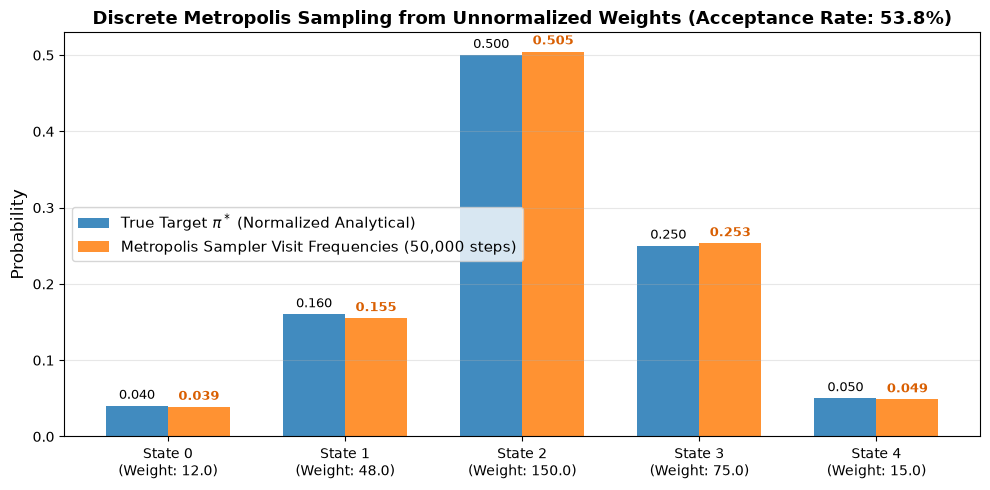

--- Comparison: True vs Empirical Frequencies ---
         Raw Weight  True Normalized pi*  Metropolis Empirical   Error
State 0        12.0                 0.04                0.0386  0.0014
State 1        48.0                 0.16                0.1550  0.0050
State 2       150.0                 0.50                0.5047  0.0047
State 3        75.0                 0.25                0.2532  0.0032
State 4        15.0                 0.05                0.0485  0.0015


In [5]:
# Demonstration: Discrete Metropolis Sampler
# Target: A distribution over 5 discrete states proportional to unnormalized weights
# Notice we DO NOT normalize these weights!
unnormalized_target = np.array([12.0, 48.0, 150.0, 75.0, 15.0])
true_normalized = unnormalized_target / unnormalized_target.sum()
states_5 = [f"State {i}" for i in range(5)]

def discrete_metropolis_sample(target_weights, steps=50000):
    n_states = len(target_weights)
    chain = np.zeros(steps, dtype=int)
    chain[0] = np.random.randint(0, n_states)  # Random start
    
    accepts = 0
    for t in range(1, steps):
        curr = chain[t-1]
        
        # 1. Symmetric proposal: randomly pick a neighboring state (left or right)
        step_dir = np.random.choice([-1, 1])
        prop = (curr + step_dir) % n_states  # Periodic boundary for clean symmetry
        
        # 2. Metropolis Acceptance Ratio
        # Notice we pass the RAW unnormalized weights!
        ratio = target_weights[prop] / target_weights[curr]
        alpha = min(1.0, ratio)
        
        # 3. Accept / Reject coin flip
        if np.random.rand() < alpha:
            chain[t] = prop
            accepts += 1
        else:
            chain[t] = curr  # Stay in place!
            
    return chain, accepts / steps

samples, acc_rate = discrete_metropolis_sample(unnormalized_target, steps=50000)
empirical_target_freqs = np.bincount(samples, minlength=5) / len(samples)

# Comparison Plot
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(5)
width = 0.35

rects1 = ax.bar(x - width/2, true_normalized, width, label=r'True Target $\pi^*$ (Normalized Analytical)', color='#1f77b4', alpha=0.85)
rects2 = ax.bar(x + width/2, empirical_target_freqs, width, label='Metropolis Sampler Visit Frequencies (50,000 steps)', color='#ff7f0e', alpha=0.85)

ax.set_ylabel('Probability', fontsize=12)
ax.set_title(f'Discrete Metropolis Sampling from Unnormalized Weights (Acceptance Rate: {acc_rate*100:.1f}%)', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f"State {i}\n(Weight: {unnormalized_target[i]})" for i in range(5)], fontsize=10)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

# Annotate bars
for rect in rects1:
    h = rect.get_height()
    ax.annotate(f'{h:.3f}', xy=(rect.get_x() + rect.get_width()/2, h), xytext=(0, 3),
                textcoords="offset points", ha='center', va='bottom', fontsize=9)
for rect in rects2:
    h = rect.get_height()
    ax.annotate(f'{h:.3f}', xy=(rect.get_x() + rect.get_width()/2, h), xytext=(0, 3),
                textcoords="offset points", ha='center', va='bottom', fontsize=9, color='#d95f02', fontweight='bold')

plt.tight_layout()
plt.show()

print("--- Comparison: True vs Empirical Frequencies ---")
df_comp = pd.DataFrame({
    "Raw Weight": unnormalized_target,
    "True Normalized pi*": true_normalized.round(4),
    "Metropolis Empirical": empirical_target_freqs.round(4),
    "Error": np.abs(empirical_target_freqs - true_normalized).round(4)
}, index=states_5)
print(df_comp)

---

## Part 6: Check Your Understanding (3-Tier Scaffolding Exercises)

---

### 🟢 Tier 1 (Conceptual): Why Not Calculate $P(y)$?

**Question**:  
Suppose you are doing Bayesian inference with 10 continuous parameters $\theta = (\theta_1, \dots, \theta_{10})$.  
Why is Detailed Balance $\pi(A) T(A \to B) = \pi(B) T(B \to A)$ the mathematical key that frees us from having to calculate the evidence integral $P(y) = \int \mathcal{L}(y \mid \theta) P(\theta) \, d\theta$?

<details>
<summary><b>🔍 Reveal Answer & Explanation</b></summary>

Because detailed balance only requires the **ratio** of probabilities between two states:
$$\frac{\alpha(A \to B)}{\alpha(B \to A)} = \frac{\pi(B)}{\pi(A)}$$

The evidence integral $P(y)$ is a constant with respect to $\theta$. It appears identically in the numerator and denominator:
$$\frac{\pi(B)}{\pi(A)} = \frac{\frac{\mathcal{L}(y \mid B) P(B)}{P(y)}}{\frac{\mathcal{L}(y \mid A) P(A)}{P(y)}} = \frac{\mathcal{L}(y \mid B) P(B)}{\mathcal{L}(y \mid A) P(A)}$$
$P(y)$ cancels out completely. We only ever need to evaluate the product of the likelihood and the prior, which is $O(1)$ to compute at any single point!
</details>

---

### 🟡 Tier 2 (Guided Calculation): Two-Room Detailed Balance Equilibrium

**Question**:  
Imagine two rooms, Room 1 and Room 2.  
* People in Room 1 have probability $P_{12} = 0.40$ of walking into Room 2.
* People in Room 2 have probability $P_{21} = 0.10$ of walking into Room 1.

Using **Detailed Balance directly**, find the stationary fraction of people in Room 1 ($\\pi_1$) and Room 2 ($\\pi_2$).

<details>
<summary><b>🔍 Reveal Answer & Derivation</b></summary>

1. Write the Detailed Balance condition between Room 1 and Room 2:
   $$\pi_1 \cdot P_{12} = \pi_2 \cdot P_{21}$$
2. Substitute the given transition rates:
   $$\pi_1 \cdot 0.40 = \pi_2 \cdot 0.10 \implies \pi_2 = 4 \pi_1$$
3. Use the normalization constraint $\pi_1 + \pi_2 = 1.0$:
   $$\pi_1 + 4\pi_1 = 1.0 \implies 5\pi_1 = 1.0 \implies \pi_1 = 0.20$$
   $$\pi_2 = 4(0.20) = 0.80$$

**Result**: At equilibrium, **$20\%$** of the people are in Room 1, and **$80\%$** are in Room 2!
</details>

---

### 🔴 Tier 3 (Production Challenge): An Automated Detailed Balance Auditor

Write a Python function `audit_detailed_balance(P, pi, tol=1e-5)` that:
1. Verifies that $P$ is a valid transition matrix (rows sum to 1, non-negative).
2. Verifies that $\pi$ is a valid probability vector (sums to 1, non-negative).
3. Verifies that $\pi$ is stationary with respect to $P$ ($\|\pi P - \pi\| < \text{tol}$).
4. Computes the maximum pairwise flow asymmetry:
   $$\Delta_{\max} = \max_{i < j} |\pi_i P_{ij} - \pi_j P_{ji}|$$
5. Returns a dictionary with boolean flags and the maximum asymmetry.

Let us implement and run this auditor on both a reversible matrix and an irreversible matrix!

In [6]:
def audit_detailed_balance(P, pi, tol=1e-5):
    P = np.asarray(P, dtype=float)
    pi = np.asarray(pi, dtype=float)
    
    # 1. Row stochasticity
    is_valid_P = np.all(P >= 0) and np.allclose(P.sum(axis=1), 1.0, atol=tol)
    
    # 2. Probability vector
    is_valid_pi = np.all(pi >= 0) and np.isclose(pi.sum(), 1.0, atol=tol)
    
    # 3. Stationarity (Global Balance)
    global_discrepancy = np.max(np.abs(pi @ P - pi))
    is_stationary = global_discrepancy < tol
    
    # 4. Detailed Balance (Pairwise Flux)
    K = len(pi)
    Flow = pi[:, None] * P
    asymmetries = []
    for i in range(K):
        for j in range(i + 1, K):
            asymmetries.append(abs(Flow[i, j] - Flow[j, i]))
            
    max_asymmetry = max(asymmetries) if asymmetries else 0.0
    satisfies_detailed_balance = max_asymmetry < tol
    
    return {
        "valid_transition_matrix": is_valid_P,
        "valid_distribution_vector": is_valid_pi,
        "is_stationary_global_balance": is_stationary,
        "satisfies_detailed_balance": satisfies_detailed_balance,
        "max_flux_asymmetry": float(max_asymmetry),
        "global_discrepancy": float(global_discrepancy)
    }

# Test 1: Our Island Matrix P
print("=== Test 1: 3-Island Transition Matrix ===")
res_islands = audit_detailed_balance(P, pi_exact)
for k, v in res_islands.items():
    print(f"  {k:30s}: {v}")

# Test 2: Symmetric Metropolis Transition Matrix from Part 5
# Construct the full transition matrix implied by our 5-state sampler
P_metro = np.zeros((5, 5))
for i in range(5):
    for move in [-1, 1]:
        j = (i + move) % 5
        q_ij = 0.5  # 50% chance to propose left or right
        alpha_ij = min(1.0, unnormalized_target[j] / unnormalized_target[i])
        P_metro[i, j] = q_ij * alpha_ij
    P_metro[i, i] = 1.0 - P_metro[i, :].sum()

print("\n=== Test 2: Discrete Metropolis Transition Matrix ===")
res_metro = audit_detailed_balance(P_metro, true_normalized)
for k, v in res_metro.items():
    print(f"  {k:30s}: {v}")

=== Test 1: 3-Island Transition Matrix ===
  valid_transition_matrix       : True
  valid_distribution_vector     : True
  is_stationary_global_balance  : True
  satisfies_detailed_balance    : False
  max_flux_asymmetry            : 0.013829787234042573
  global_discrepancy            : 5.551115123125783e-17

=== Test 2: Discrete Metropolis Transition Matrix ===
  valid_transition_matrix       : True
  valid_distribution_vector     : True
  is_stationary_global_balance  : True
  satisfies_detailed_balance    : True
  max_flux_asymmetry            : 3.469446951953614e-18
  global_discrepancy            : 6.938893903907228e-18


---

## 🚀 Looking Ahead: Bridging from Discrete States to Continuous Parameters

You now possess the foundational mathematical concepts required to master MCMC:
1. **The Markov Chain**: A memoryless sequence of states.
2. **The Transition Kernel**: The rule governing moves.
3. **The Stationary Distribution**: The equilibrium invariant distribution $\pi P = \pi$.
4. **Detailed Balance**: Pairwise equilibrium $\pi(A) T(A \to B) = \pi(B) T(B \to A)$.
5. **The Metropolis Engine**: How accepting proposals with probability $\min\left(1, \frac{\pi(B)}{\pi(A)}\right)$ forces detailed balance to hold, enabling us to sample from unnormalized posteriors!

In **[Sheet 4: First Principles — MCMC Mechanics from Scratch](04_mcmc_mechanics_from_scratch.ipynb)**, we generalize these discrete concepts to **continuous multidimensional parameter spaces $\theta \in \mathbb{R}^D$**:
* Instead of jumping between 3 islands, our walker hops smoothly along continuous curves.
* Instead of a transition matrix $P_{ij}$, we use a continuous proposal density $q(\theta^* \mid \theta^{(t)}) = \mathcal{N}(\theta^{(t)}, \tau^2)$.
* The core Metropolis rule remains **100% identical**.

---

**[🏠 Course Home](00_START_HERE.ipynb) | ◀️ Previous: [Sheet 3: Rapid Prototyping — Quadratic (Laplace / QUAP) Approximation](03_quadratic_laplace_approximation.ipynb) | ▶️ Next: [Sheet 4: First Principles — MCMC Mechanics from Scratch](04_mcmc_mechanics_from_scratch.ipynb)**